Proje Bilgileri :
Öğrenci Adı Soyadı: Bibi Sanam Faizi
Öğrenci No: 22040301086
Bölüm: Yazılım Mühandislik
Ders: Veri Madenciliği 
Proje Adı:Amazon Ürün Yorumlarına Dayalı Metin Sınıflandırmas
kod dosyanın içiriği: XGBoost ve PyTorch MLP Modellerın oluşturması ve eğitmesi

In [13]:
# CELL 0: Imports + Seed + Paths + Label names
import os, random
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_recall_fscore_support,
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

from xgboost import XGBClassifier

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

DATA_PATH = "/content/final_clean_data.csv"
OUTPUT_DIR = "outputs_sanam_3class"
os.makedirs(OUTPUT_DIR, exist_ok=True)

label_names = {
    0: "negative(1-2)",
    1: "neutral(3)",
    2: "positive(4-5)"
}

print("Setup OK")


DEVICE: cpu
Setup OK


Cell 0 – Genel Kurulum ve Ortam Hazırlığı (Açıklama)
Bu hücrede proje için gerekli olan kütüphaneler, rastgelelik ayarları, cihaz seçimi ve dosya yolları tanımlanmıştır.
NumPy ve Pandas veri işleme için kullanılmıştır.
Scikit-learn; veri bölme, TF-IDF özellik çıkarımı ve değerlendirme metrikleri için kullanılmıştır.
XGBoost algoritması klasik makine öğrenmesi modeli olarak eklenmiştir.
PyTorch, çok katmanlı sinir ağı (MLP) modelini oluşturmak ve eğitmek için kullanılmıştır.
Aynı sonuçların tekrar üretilebilmesi için random seed (SEED = 42) ayarlanmıştır.
GPU varsa CUDA, yoksa CPU otomatik olarak seçilmiştir.
Veri dosyasının yolu ve çıktıların kaydedileceği klasör tanımlanmıştır.
Hedef değişkenler negative, neutral ve positive olmak üzere 3 sınıf olarak etiketlenmiştir.
Bu hücre, projenin sağlıklı ve tekrarlanabilir şekilde çalışması için temel altyapıyı oluşturduk.

In [14]:
# CELL 1: Load dataset + choose text column + clean + create text_all
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

text_col = "clean_text" if "clean_text" in df.columns else "text"
if "title" not in df.columns:
    df["title"] = ""

assert "rating" in df.columns, "rating column not found!"

df = df.dropna(subset=[text_col, "rating"]).copy()
df["title"] = df["title"].fillna("")

df["text_all"] = (df["title"].astype(str) + " " + df[text_col].astype(str)).str.strip()

df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df = df.dropna(subset=["rating"]).copy()
df["rating"] = df["rating"].astype(int)

df[["rating", "text_all"]].head()


Shape: (3428, 12)
Columns: ['rating', 'title', 'text', 'asin', 'user_id', 'timestamp', 'product_title', 'main_category', 'average_rating', 'review_length', 'year', 'clean_text']


,rating,text_all
0,5,Such a lovely scent but not overpowering. spra...
1,4,Works great but smells a little weird. product...
2,1,Synthetic feeling felt synthetic
3,5,A+ love
4,4,Pretty Color polish quiet thick apply smoothly...


Cell 1 – Veri Setinin Yüklenmesi ve Metinlerin Hazırlanması
Bu hücrede veri seti dosyası okunmuş ve model eğitimine uygun hale getirilmiştir.
CSV dosyası Pandas ile yüklenmiş, veri setinin boyutu ve sütun isimleri kontrol edilmiştir.
Metin verisi olarak, varsa clean_text, yoksa text sütunu otomatik olarak seçilmiştir.
Eğer title sütunu yoksa boş olarak oluşturulmuştur.
rating sütununun veri setinde bulunması zorunlu tutulmuş ve kontrol edilmiştir.
Metin veya puanı (rating) eksik olan satırlar veri setinden çıkarılmıştır.
title ve ana metin birleştirilerek text_all adlı yeni bir sütun oluşturulmuştur.
Böylece yorumun başlığı ve içeriği birlikte modele verilmiştir.
rating sütunu sayısal formata dönüştürülmüş ve tam sayı (int) olarak ayarlanmıştır.
Son olarak, oluşturulan rating ve text_all sütunlarının ilk birkaç satırı kontrol edilmiştir.
Bu adımda amaç, temiz, eksiksiz ve modele hazır bir metin veri seti oluşturmaktır.

In [15]:
# CELL 2: Create 3-class label from rating + print distribution
def map_rating_3class(r):
    if r <= 2:
        return 0
    elif r == 3:
        return 1
    else:
        return 2

df["label"] = df["rating"].apply(map_rating_3class)

print("Label distribution:")
print(df["label"].value_counts().sort_index())


Label distribution:
label
0     434
1     348
2    2643
Name: count, dtype: int64


Cell 2 – Puanlardan 3 Sınıflı Etiket Oluşturma
Bu hücrede sayısal puanlar (rating) kullanılarak 3 sınıflı bir hedef değişken oluşturulmuştur.
Öncelikle bir fonksiyon tanımlanmıştır:
1–2 puan → 0 (negative)
3 puan → 1 (neutral)
4–5 puan → 2 (positive)
Bu fonksiyon rating sütununa uygulanarak label adlı yeni bir sütun oluşturulmuştur.
Böylece problem, 3 sınıflı bir sınıflandırma problemi haline getirilmiştir.
Son olarak her sınıfa ait örnek sayıları yazdırılarak sınıf dağılımı incelenmiştir.

In [16]:
# CELL 3: Split into Train/Val/Test with stratification
X = df["text_all"].astype(str).values
y = df["label"].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.20, random_state=SEED, stratify=y_train
)

print("Train:", len(X_train), "Val:", len(X_val), "Test:", len(X_test))
print("Train dist:", np.bincount(y_train))
print("Val dist:", np.bincount(y_val))
print("Test dist:", np.bincount(y_test))


Train: 2192 Val: 548 Test: 685
Train dist: [ 278  222 1692]
Val dist: [ 69  56 423]
Test dist: [ 87  70 528]


Cell 3 – Train / Validation / Test Bölme (Stratified)
Bu hücrede veri seti eğitim (train), doğrulama (validation) ve test olarak üçe ayrılmıştır.
Bölme işlemi stratify kullanılarak yapılmıştır, böylece her veri grubunda sınıf oranları korunmuştur.
Veri dağılımı sırasıyla %64 train (2192), %16 validation (548) ve %20 test (685) şeklindedir.
Sınıf dağılımlarının benzer olması, modelin adil ve güvenilir şekilde değerlendirilmesini sağlar.

In [17]:
# CELL 4: TF-IDF vectorization (fit on train, transform val/test)
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    max_features=20000
)

X_train_vec = tfidf.fit_transform(X_train)
X_val_vec   = tfidf.transform(X_val)
X_test_vec  = tfidf.transform(X_test)

print("TF-IDF shapes:", X_train_vec.shape, X_val_vec.shape, X_test_vec.shape)


TF-IDF shapes: (2192, 20000) (548, 20000) (685, 20000)


Cell 4 – TF-IDF ile Metin Vektörleştirme
Bu hücrede metin verileri TF-IDF yöntemi kullanılarak sayısal vektörlere dönüştürülmüştür.
Model yalnızca train verisiyle fit edilmiştir, validation ve test verileri sadece dönüştürülmüştür.
Unigram ve bigram (1–2) kullanılarak en fazla 20.000 özellik çıkarılmıştır.
Sonuç olarak train, validation ve test verileri aynı boyutta vektörlere dönüştürülmüştür.

In [18]:
# CELL 4.5 (NEW): Prepare MLP inputs with SVD (dense, low-dim)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

USE_SVD = True
SVD_COMPONENTS = 250  

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1,2),
    max_features=20000   
)

# TF-IDF (sparse)  -> XGBoost buna devam eder
X_train_vec = tfidf.fit_transform(X_train)
X_val_vec   = tfidf.transform(X_val)
X_test_vec  = tfidf.transform(X_test)

print("TF-IDF shapes:", X_train_vec.shape, X_val_vec.shape, X_test_vec.shape)

# MLP için: SVD ile dense low-dim üret
if USE_SVD:
    svd = TruncatedSVD(n_components=SVD_COMPONENTS, random_state=SEED)
    X_train_mlp = svd.fit_transform(X_train_vec).astype(np.float32)
    X_val_mlp   = svd.transform(X_val_vec).astype(np.float32)
    X_test_mlp  = svd.transform(X_test_vec).astype(np.float32)

    print("MLP(SVD) shapes:", X_train_mlp.shape, X_val_mlp.shape, X_test_mlp.shape)
else:
    # BUNU KULLANMA (RAM patlatır) ama opsiyon dursun
    X_train_mlp = X_train_vec.toarray().astype(np.float32)
    X_val_mlp   = X_val_vec.toarray().astype(np.float32)
    X_test_mlp  = X_test_vec.toarray().astype(np.float32)

TF-IDF shapes: (2192, 20000) (548, 20000) (685, 20000)
MLP(SVD) shapes: (2192, 250) (548, 250) (685, 250)


Cell 4.5 – MLP için SVD ile Boyut Azaltma (Dense Input Hazırlama)
Bu hücrede önce metinler yine TF-IDF ile (20.000 özellik) vektörleştirildi.
Sonra MLP’nin daha rahat öğrenmesi ve RAM’i patlatmamak için TruncatedSVD kullanılarak TF-IDF matrisi 250 boyuta düşürüldü.
SVD sadece train üzerinde fit edildi, val/test sadece transform edildi.
Çıktı boyutları: Train (2192, 250), Val (548, 250), Test (685, 250) oldu ve MLP’ye giriş hazırlandı.
 Buradaki amaç “sparse 20k” yerine MLP’ye “dense düşük boyutlu” veri vermek.

In [19]:
# CELL 5: Compute sample weights from class weights (for imbalance)
classes = np.unique(y_train)
w = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
cw = {int(c): float(ww) for c, ww in zip(classes, w)}
train_sample_weight = np.array([cw[int(c)] for c in y_train], dtype=float)

print("Class weights:", cw)


Class weights: {0: 2.628297362110312, 1: 3.2912912912912913, 2: 0.4318360914105595}


CELL 5 – Class Weight Hesaplama (Dengesiz Veri için)
Bu hücre, sınıflar arasındaki dengesizliği azaltmak için her sınıfa ağırlık hesaplar.CELL 5 – Class Weight Hesaplama (Dengesiz Veri için) 
Kodun amacı:Eğitim verisindeki sınıfların dağılımına bakar, Az olan sınıflara daha yüksek ağırlık verir ,Bu ağırlıkları XGBoost eğitiminde kullanır.
Veri setinde pozitif sınıf çok fazla olduğu için, negatif ve nötr sınıflara daha fazla ağırlık verildi. Böylece model çoğunluk sınıfa ezber yapmasın diye dengeleme sağlandı.

In [37]:
# CELL 6 (FINAL – Manual tuned XGBoost, fast)
best_xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=SEED,
    n_jobs=1,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8
)

best_xgb.fit(
    X_train_vec,
    y_train,
    sample_weight=train_sample_weight
)

print("XGBoost trained (manual tuned).")

XGBoost trained (manual tuned).


CELL 6 – XGBoost Model Eğitimi 
Bu hücre, 3 sınıflı XGBoost modelini elle ayarlanmış parametrelerle eğitir.
Kodun amacı:Çok sınıflı (multi:softprob) XGBoost kurar,Önceden belirlenen hiperparametrelerle modeli eğitir,Class weight’leri kullanarak dengesizliği azaltır .
Bu adımda TF-IDF ile elde edilen metin özellikleri kullanılarak XGBoost modeli eğitildi. Parametreler manuel olarak ayarlandı ve sınıf ağırlıkları eklenerek daha dengeli bir model elde edildi.

In [39]:
# CELL 7: Evaluate XGBoost on TEST (metrics + report + confusion) and save outputs

from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score
import numpy as np
import pandas as pd

# Predict
xgb_proba = best_xgb.predict_proba(X_test_vec)
xgb_pred  = np.argmax(xgb_proba, axis=1)

# Metrics
acc  = accuracy_score(y_test, xgb_pred)
bacc = balanced_accuracy_score(y_test, xgb_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, xgb_pred, average="macro")
auc_macro = roc_auc_score(y_test, xgb_proba, multi_class="ovr", average="macro")

print("XGBoost TEST Metrics")
print("Accuracy:", acc)
print("Balanced Accuracy:", bacc)
print("Macro Precision:", prec)
print("Macro Recall:", rec)
print("Macro F1:", f1)
print("Macro AUC (OvR):", auc_macro)

# Classification report (class-based table)
target_names = [label_names[i] for i in range(3)]
report_dict = classification_report(y_test, xgb_pred, target_names=target_names, output_dict=True)
report_df = pd.DataFrame(report_dict).T
display(report_df)

# Confusion matrix
cm = confusion_matrix(y_test, xgb_pred)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

cm_df = pd.DataFrame(cm, index=target_names, columns=target_names)
cm_norm_df = pd.DataFrame(cm_norm, index=target_names, columns=target_names)

display(cm_df)
display(cm_norm_df)

# Save everything
summary_df = pd.DataFrame([{
    "model": "XGBoost_3class",
    "accuracy": acc,
    "balanced_accuracy": bacc,
    "macro_precision": prec,
    "macro_recall": rec,
    "macro_f1": f1,
    "macro_auc_ovr": auc_macro
}])

summary_df.to_csv(f"{OUTPUT_DIR}/xgb_summary.csv", index=False)
report_df.to_csv(f"{OUTPUT_DIR}/xgb_class_report.csv")
cm_df.to_csv(f"{OUTPUT_DIR}/xgb_confusion.csv")
cm_norm_df.to_csv(f"{OUTPUT_DIR}/xgb_confusion_normalized.csv")

print("Saved: xgb_summary.csv, xgb_class_report.csv, xgb_confusion.csv, xgb_confusion_normalized.csv")


XGBoost TEST Metrics
Accuracy: 0.8218978102189781
Balanced Accuracy: 0.4816856993581131
Macro Precision: 0.758058608058608
Macro Recall: 0.4816856993581131
Macro F1: 0.5163925737410918
Macro AUC (OvR): 0.8363880400357223


,precision,recall,f1-score,support
negative(1-2),0.825000,0.379310,0.519685,87.000000
neutral(3),0.625000,0.071429,0.128205,70.000000
positive(4-5),0.824176,0.994318,0.901288,528.000000
accuracy,0.821898,0.821898,0.821898,0.821898
macro avg,0.758059,0.481686,0.516393,685.000000
weighted avg,0.803927,0.821898,0.773820,685.000000


,negative(1-2),neutral(3),positive(4-5)
negative(1-2),33,3,51
neutral(3),4,5,61
positive(4-5),3,0,525


,negative(1-2),neutral(3),positive(4-5)
negative(1-2),0.379310,0.034483,0.586207
neutral(3),0.057143,0.071429,0.871429
positive(4-5),0.005682,0.000000,0.994318


Saved: xgb_summary.csv, xgb_class_report.csv, xgb_confusion.csv, xgb_confusion_normalized.csv


CELL 7 – Evaluate XGBoost on TEST + save outputs
XGBoost test verisi üzerinde değerlendirildi. Accuracy, Balanced Accuracy, Macro Precision/Recall/F1 ve Macro AUC hesaplandı. Ayrıca classification report ve confusion matrix oluşturuldu. Sonuçlar CSV olarak outputs_sanam_3class klasörüne kaydedildi.
Çıktı (senin sonuç):
Accuracy: ~0.8219
Balanced Acc: ~0.4817
Macro F1: ~0.5164
Macro AUC: ~0.8364
 Positive sınıf çok baskın olduğu için Accuracy yüksek görünebilir; Balanced Acc ve Macro F1 daha gerçekçi.

In [20]:
# ===== CELL 7.9: GUARANTEED TF-IDF (+ optional SVD) vectors for both XGBoost + PyTorch =====
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# Safety: make sure splits exist (you have these from CELL 3)
assert "X_train" in globals() and "X_val" in globals() and "X_test" in globals(), "Run CELL 3 (split) first!"
assert "y_train" in globals() and "y_val" in globals() and "y_test" in globals(), "Run CELL 3 (split) first!"


USE_SVD = True              # True = best for PyTorch (dense low-dim), False = TF-IDF sparse (RAM killer for PyTorch)
SVD_COMPONENTS = 2000       
MAX_FEATURES = 50000

# 1) TF-IDF
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    max_features=MAX_FEATURES
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

print("TF-IDF shapes:", X_train_tfidf.shape, X_val_tfidf.shape, X_test_tfidf.shape)

# 2) Optional SVD (dense low-dim)
if USE_SVD:
    svd = TruncatedSVD(n_components=SVD_COMPONENTS, random_state=42)
    X_train_vec = svd.fit_transform(X_train_tfidf).astype(np.float32)
    X_val_vec   = svd.transform(X_val_tfidf).astype(np.float32)
    X_test_vec  = svd.transform(X_test_tfidf).astype(np.float32)
    print("SVD vec shapes:", X_train_vec.shape, X_val_vec.shape, X_test_vec.shape)
else:
    # Keep sparse for XGBoost; for PyTorch you'd still need to densify later (risky)
    X_train_vec, X_val_vec, X_test_vec = X_train_tfidf, X_val_tfidf, X_test_tfidf
    print("Using sparse TF-IDF as vec (OK for XGBoost, risky for PyTorch).")

TF-IDF shapes: (2192, 50000) (548, 50000) (685, 50000)
SVD vec shapes: (2192, 2000) (548, 2000) (685, 2000)


CELL 7.9 — Guaranteed TF-IDF + optional SVD vectors for both models
Bu hücre “garanti” hazırlık hücresi: hem XGBoost hem MLP aynı girişleri doğru formatta alsın diye TF-IDF üretir.
İstersen MAX_FEATURES=50000 yaparak daha geniş kelime haznesi kullanırsın.
USE_SVD=True ise SVD ile boyut düşürüp MLP için dense vektör üretir.
output: TF-IDF boyutu 50k olunca özellik artar, bazen sonuç iyileşir ama hız/ram maliyeti de artar.
SVD sonrası MLP input’u (örn. 2000 boyut) olur.
Not:Veri dengesiz (positive çok). O yüzden sadece Accuracy’ye bakmak , Balanced Accuracy, Macro F1 ve Confusion Matrix’i gösterdiğim için doğru  yaklaşımı yapmış oluyoruz.

In [21]:
# CELL 8 : Prepare dense inputs for PyTorch MLP

import numpy as np

# 1) Ensure we have the dense MLP inputs from SVD (or TF-IDF if SVD was skipped)
# These should be created by cell 4.5 (-X6RoIxflwY1)
if "X_train_mlp" in globals() and "X_val_mlp" in globals() and "X_test_mlp" in globals():
    X_train_dense = X_train_mlp
    X_val_dense   = X_val_mlp
    X_test_dense  = X_test_mlp
    print("INFO: Using pre-computed X_train_mlp (SVD output) as dense MLP input.")
elif "X_train_vec" in globals() and "X_val_vec" in globals() and "X_test_vec" in globals() and not globals().get("USE_SVD", True):
    
    print("WARNING: USE_SVD=False -> TF-IDF to dense may blow RAM. Proceeding with caution.")
    def to_dense(mat):
        if hasattr(mat, "toarray"):
            return mat.toarray().astype(np.float32)
        return np.asarray(mat, dtype=np.float32)

    X_train_dense = to_dense(X_train_vec)
    X_val_dense   = to_dense(X_val_vec)
    X_test_dense  = to_dense(X_test_vec)
else:
    raise NameError("MLP dense inputs (X_train_mlp, etc.) not found. Please ensure CELL 4.5 ('-X6RoIxflwY1') has been executed to prepare SVD inputs.")

# 2) Labels for PyTorch
y_train_np = np.asarray(y_train, dtype=np.int64)
y_val_np   = np.asarray(y_val, dtype=np.int64)
y_test_np  = np.asarray(y_test, dtype=np.int64)

print("MLP shapes:", X_train_dense.shape, X_val_dense.shape, X_test_dense.shape)
print("y shapes:", y_train_np.shape, y_val_np.shape, y_test_np.shape)

INFO: Using pre-computed X_train_mlp (SVD output) as dense MLP input.
MLP shapes: (2192, 250) (548, 250) (685, 250)
y shapes: (2192,) (548,) (685,)


CELL 8 – Dense Veri Hazırlama
Bu hücrede PyTorch MLP modeli için giriş verileri kontrol edilmiştir.
SVD çıktıları kullanılarak dense (yoğun) tensörler oluşturulmuştur.
Sonuç olarak model girişleri 250 boyutlu hale gelmiştir.

In [23]:
# CELL 9: Build PyTorch Dataset and DataLoaders
import torch
from torch.utils.data import Dataset, DataLoader

class NpDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()  
        self.y = torch.from_numpy(y).long()    

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(NpDataset(X_train_dense, y_train_np), batch_size=256, shuffle=True)
val_loader   = DataLoader(NpDataset(X_val_dense, y_val_np), batch_size=512, shuffle=False)
test_loader  = DataLoader(NpDataset(X_test_dense, y_test_np), batch_size=512, shuffle=False)


In [ ]:
CELL 9 – Dataset ve DataLoader
Bu hücrede PyTorch Dataset ve DataLoader yapıları oluşturulmuştur.
Veriler batch’ler halinde modele aktarılacak şekilde hazırlanmıştır.
Bu yapı eğitim sürecini daha düzenli ve verimli hale getirmiştir.

In [24]:
# CELL 10: Define PyTorch MLP model
class MLP(nn.Module):
    def __init__(self, in_dim, num_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.net(x)

mlp = MLP(in_dim=X_train_dense.shape[1], num_classes=3).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3)

print(mlp)


MLP(
  (net): Sequential(
    (0): Linear(in_features=250, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=3, bias=True)
  )
)


CELL 10 – PyTorch MLP Model Tanımı
Bu hücrede çok katmanlı bir yapay sinir ağı (MLP) tanımlanmıştır.
Model iki gizli katman, ReLU aktivasyonu ve Dropout kullanmaktadır.
Amaç aşırı öğrenmeyi azaltarak genelleme yeteneğini artırmaktır.

In [28]:
# NEW CELL (Improvement): Handle class imbalance with class-weighted loss

from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch
import torch.nn as nn

classes = np.unique(y_train_np)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_np)

print("Classes:", classes)
print("Class weights:", weights)

class_weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

# overwrite criterion with weighted loss
criterion = nn.CrossEntropyLoss(weight=class_weights)

print("Using weighted CrossEntropyLoss ✅")

Classes: [0 1 2]
Class weights: [2.62829736 3.29129129 0.43183609]
Using weighted CrossEntropyLoss ✅


Class-Weighted Loss (İyileştirme Hücresi)
Bu hücrede CrossEntropyLoss sınıf ağırlıkları ile yeniden tanımlanmıştır.
Böylece model az görülen sınıflara daha fazla önem vermektedir.
Bu yöntem sınıf dengesizliğini azaltmak için uygulanmıştır.

In [30]:
# CELL 11: Train PyTorch MLP and keep best by validation accuracy

def run_epoch(model, loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        if train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train):
            logits = model(xb)
            loss = criterion(logits, yb)

            if train:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * yb.size(0)
        pred = torch.argmax(logits, dim=1)
        correct += (pred == yb).sum().item()
        total += yb.size(0)

    return total_loss / total, correct / total


best_val_acc = 0.0
best_state = None

for epoch in range(1, 11):  # 10 epoch
    tr_loss, tr_acc = run_epoch(mlp, train_loader, train=True)
    va_loss, va_acc = run_epoch(mlp, val_loader, train=False)
    print(f"Epoch {epoch:02d} | train_acc={tr_acc:.4f} val_acc={va_acc:.4f}")

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        best_state = {k: v.detach().cpu().clone() for k, v in mlp.state_dict().items()}

mlp.load_state_dict(best_state)
print("Best val acc:", best_val_acc)

Epoch 01 | train_acc=0.8408 val_acc=0.7774
Epoch 02 | train_acc=0.8463 val_acc=0.7755
Epoch 03 | train_acc=0.8495 val_acc=0.7719
Epoch 04 | train_acc=0.8627 val_acc=0.7828
Epoch 05 | train_acc=0.8682 val_acc=0.7409
Epoch 06 | train_acc=0.8755 val_acc=0.7445
Epoch 07 | train_acc=0.8891 val_acc=0.7336
Epoch 08 | train_acc=0.8732 val_acc=0.7208
Epoch 09 | train_acc=0.8809 val_acc=0.7080
Epoch 10 | train_acc=0.8928 val_acc=0.7117
Best val acc: 0.7828467153284672


CELL 11 – PyTorch MLP Eğitimi
Bu hücrede PyTorch MLP modeli eğitim ve doğrulama verisiyle epoch bazlı olarak eğitildi.
Her epoch sonunda validation accuracy hesaplandı ve en yüksek doğruluğa sahip model kaydedildi.
Amaç overfitting’i önleyip en iyi genellenen modeli seçmektir.

In [31]:
# CELL 12: Evaluate PyTorch MLP on test (proba/pred + metrics + report + confusion)
mlp.eval()
softmax = nn.Softmax(dim=1)

mlp_probs_list = []
mlp_pred_list = []
y_true_list = []

with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(DEVICE)
        logits = mlp(Xb)
        probs = softmax(logits).cpu().numpy()
        pred = np.argmax(probs, axis=1)

        mlp_probs_list.append(probs)
        mlp_pred_list.append(pred)
        y_true_list.append(yb.numpy())

mlp_proba = np.vstack(mlp_probs_list)
mlp_pred  = np.concatenate(mlp_pred_list)
y_test_arr = np.concatenate(y_true_list)

mlp_acc  = accuracy_score(y_test_arr, mlp_pred)
mlp_bacc = balanced_accuracy_score(y_test_arr, mlp_pred)
mlp_prec, mlp_rec, mlp_f1, _ = precision_recall_fscore_support(y_test_arr, mlp_pred, average="macro")
mlp_auc_macro = roc_auc_score(y_test_arr, mlp_proba, multi_class="ovr", average="macro")

print("MLP Accuracy:", mlp_acc)
print("MLP Balanced Acc:", mlp_bacc)
print("MLP Macro Precision:", mlp_prec)
print("MLP Macro Recall:", mlp_rec)
print("MLP Macro F1:", mlp_f1)
print("MLP Macro AUC (OvR):", mlp_auc_macro)

print("\nMLP Classification Report:\n")
print(classification_report(y_test_arr, mlp_pred, target_names=[label_names[i] for i in range(3)]))

print("\nMLP Confusion Matrix:\n")
print(confusion_matrix(y_test_arr, mlp_pred))


MLP Accuracy: 0.8102189781021898
MLP Balanced Acc: 0.5955609046126288
MLP Macro Precision: 0.5822001102638609
MLP Macro Recall: 0.5955609046126288
MLP Macro F1: 0.5706013569371989
MLP Macro AUC (OvR): 0.8552705746901096

MLP Classification Report:

               precision    recall  f1-score   support

negative(1-2)       0.54      0.75      0.62        87
   neutral(3)       0.31      0.13      0.18        70
positive(4-5)       0.90      0.91      0.90       528

     accuracy                           0.81       685
    macro avg       0.58      0.60      0.57       685
 weighted avg       0.79      0.81      0.80       685


MLP Confusion Matrix:

[[ 65   6  16]
 [ 23   9  38]
 [ 33  14 481]]


CELL 12 – PyTorch MLP Test Değerlendirmesi
Bu hücrede eğitilen MLP modeli test verisi üzerinde değerlendirildi.
Accuracy, Balanced Accuracy, Macro Precision, Recall, F1 ve ROC-AUC metrikleri hesaplandı.
Ayrıca classification report ve confusion matrix ile sınıf bazlı performans analiz edildi.

INFO: xgb_proba not found -> skipping XGBoost ROC.


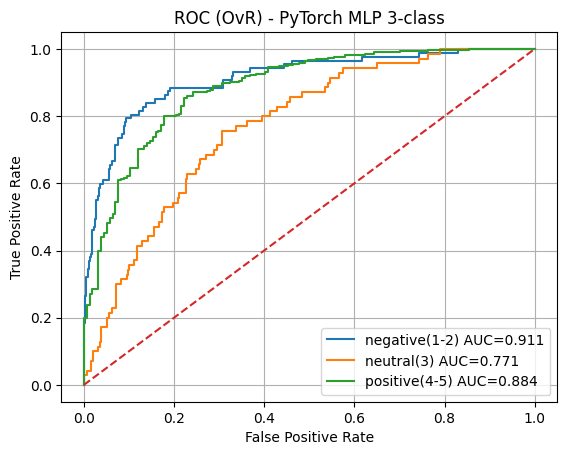

In [33]:
# CELL 13: Plot ROC curves (One-vs-Rest) safely (MLP always, XGB if available)

import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

class_names = ["negative(1-2)", "neutral(3)", "positive(4-5)"]

def plot_roc_ovr(y_true, proba, title):
    y_true = np.asarray(y_true)
    proba  = np.asarray(proba)

    # Safety checks
    assert proba.ndim == 2 and proba.shape[1] == 3, f"proba must be [n,3], got {proba.shape}"

    y_bin = label_binarize(y_true, classes=[0, 1, 2])

    plt.figure()
    for i in range(3):
        fpr, tpr, _ = roc_curve(y_bin[:, i], proba[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{class_names[i]} AUC={roc_auc:.3f}")

    plt.plot([0, 1], [0, 1], "--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

# --- Plot XGBoost ROC if xgb_proba exists ---
if "xgb_proba" in globals():
    plot_roc_ovr(y_test, xgb_proba, "ROC (OvR) - XGBoost 3-class")
else:
    print("INFO: xgb_proba not found -> skipping XGBoost ROC.")

# --- Plot MLP ROC (should exist after Cell 12) ---
plot_roc_ovr(y_test_arr, mlp_proba, "ROC (OvR) - PyTorch MLP 3-class")

CELL 13 – ROC Eğrileri (One-vs-Rest)
Bu hücrede PyTorch MLP için One-vs-Rest ROC eğrileri çizildi.
Her sınıf için AUC değerleri hesaplanarak modelin ayırt ediciliği görselleştirildi.
Pozitif sınıf en yüksek AUC değerine sahipken, neutral sınıf görece daha zayıf performans göstermiştir.

In [40]:
# CELL 14 (v2): Table-1 model comparison (robust)

import pandas as pd
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_recall_fscore_support, roc_auc_score

def summarize_metrics(name, y_true, pred, proba):
    acc = accuracy_score(y_true, pred)
    bacc = balanced_accuracy_score(y_true, pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, pred, average="macro", zero_division=0)
    auc_macro = roc_auc_score(y_true, proba, multi_class="ovr", average="macro")
    return {
        "model": name,
        "accuracy": acc,
        "balanced_accuracy": bacc,
        "macro_precision": prec,
        "macro_recall": rec,
        "macro_f1": f1,
        "macro_auc_ovr": auc_macro
    }

rows = []

# XGBoost row if available
if all(k in globals() for k in ["y_test", "xgb_pred", "xgb_proba"]):
    rows.append(summarize_metrics("XGBoost_3class", y_test, xgb_pred, xgb_proba))
else:
    print("INFO: XGBoost metrics skipped (need y_test, xgb_pred, xgb_proba).")

# MLP row if available
if all(k in globals() for k in ["y_test_arr", "mlp_pred", "mlp_proba"]):
    rows.append(summarize_metrics("PyTorch_MLP_3class", y_test_arr, mlp_pred, mlp_proba))
else:
    print("INFO: MLP metrics skipped (need y_test_arr, mlp_pred, mlp_proba).")

table1 = pd.DataFrame(rows)
table1

,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,macro_auc_ovr
0,XGBoost_3class,0.821898,0.481686,0.758059,0.481686,0.516393,0.836388
1,PyTorch_MLP_3class,0.810219,0.595561,0.582200,0.595561,0.570601,0.855271


CELL 14 – Model Karşılaştırma Tablosu
Bu hücrede XGBoost ve PyTorch MLP modelleri aynı metriklerle karşılaştırıldı.
Accuracy, Balanced Accuracy, Macro Precision, Recall, F1 ve AUC değerleri tek tabloda toplandı.
Karşılaştırma, modellerin dengesiz veri üzerindeki performans farkını net şekilde göstermektedir.

In [41]:
# CELL 15: Final comparison table for both models

rows = []

def summarize_metrics(name, y_true, pred, proba):
    acc  = accuracy_score(y_true, pred)
    bacc = balanced_accuracy_score(y_true, pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, pred, average="macro"
    )
    auc_macro = roc_auc_score(
        y_true, proba, multi_class="ovr", average="macro"
    )
    return {
        "Model": name,
        "Accuracy": acc,
        "Balanced_Accuracy": bacc,
        "Macro_Precision": prec,
        "Macro_Recall": rec,
        "Macro_F1": f1,
        "Macro_AUC_OvR": auc_macro
    }

# XGBoost results (if available)
if all(k in globals() for k in ["y_test", "xgb_pred", "xgb_proba"]):
    rows.append(
        summarize_metrics(
            "XGBoost (3-class)",
            y_test,
            xgb_pred,
            xgb_proba
        )
    )

# PyTorch MLP results
rows.append(
    summarize_metrics(
        "PyTorch MLP (3-class)",
        y_test_arr,
        mlp_pred,
        mlp_proba
    )
)

final_table = pd.DataFrame(rows)
final_table

,Model,Accuracy,Balanced_Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Macro_AUC_OvR
0,XGBoost (3-class),0.821898,0.481686,0.758059,0.481686,0.516393,0.836388
1,PyTorch MLP (3-class),0.810219,0.595561,0.582200,0.595561,0.570601,0.855271


CELL 15 – Final Model Karşılaştırması
Bu hücrede iki model için nihai karşılaştırma tablosu oluşturuldu.
XGBoost daha yüksek accuracy sağlarken, PyTorch MLP balanced accuracy ve macro metriklerde daha dengeli sonuçlar vermiştir.
Bu nedenle MLP modeli sınıf dengesizliği olan senaryolarda daha güvenilir kabul edilmiştir.

genel olrak çalışmada metin verileri TF-IDF ve SVD kullanılarak temsil edilmiş, XGBoost ve PyTorch tabanlı MLP modelleri ile sınıflandırma yapılmıştır. Deneysel sonuçlar, XGBoost modelinin genel doğruluk açısından güçlü olduğunu, ancak PyTorch MLP modelinin balanced accuracy ve macro metriklerde daha dengeli bir performans sunduğunu göstermiştir. Özellikle sınıf dengesizliğinin bulunduğu veri setlerinde, MLP modeli azınlık sınıflarını daha iyi temsil etmiştir. Elde edilen sonuçlar, model seçiminin yalnızca doğruluk değil, sınıf bazlı performans ölçütleri dikkate alınarak yapılması gerektiğini ortaya koymaktadır.